In [3]:
import glob
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import numpy as np
import tensorflow as tf
from tensorflow import io as tf_io
from tensorflow import data as tf_data

In [2]:
images = glob.glob('../data/data*/data*/CameraRGB/*.png')
masks = glob.glob('../data/data*/data*/CameraSeg/*.png')

In [4]:
def get_dataset(batch_size, img_paths, mask_paths):
    def load_imgs(img_path, mask_path):
        input_img = tf_io.read_file(img_path)
        input_img = tf_io.decode_png(input_img, channels=3)
        input_img = tf.image.convert_image_dtype(input_img, tf.float32)
        input_img = tf.image.resize(input_img, (512,512), method='nearest')

        input_mask = tf_io.read_file(mask_path)
        input_mask = tf_io.decode_png(input_mask, channels=3)
        input_mask = tf.math.reduce_max(input_mask, axis=-1, keepdims=True)
        input_mask = tf.image.resize(input_mask, (512,512), method='nearest')

        return input_img, input_mask
    image_list = tf.constant(img_paths)
    mask_list = tf.constant(mask_paths)
    dataset = tf_data.Dataset.from_tensor_slices((image_list, mask_list))
    dataset = dataset.map(load_imgs, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.cache().batch(batch_size)

In [5]:
def display(display_list):
    plt.figure(figsize=(15,15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(in_model, dataset, num=1):
    for image, mask in dataset.take(num):
        pred_mask = in_model.predict(image)
        display([image[0], mask[0], create_mask(pred_mask)])

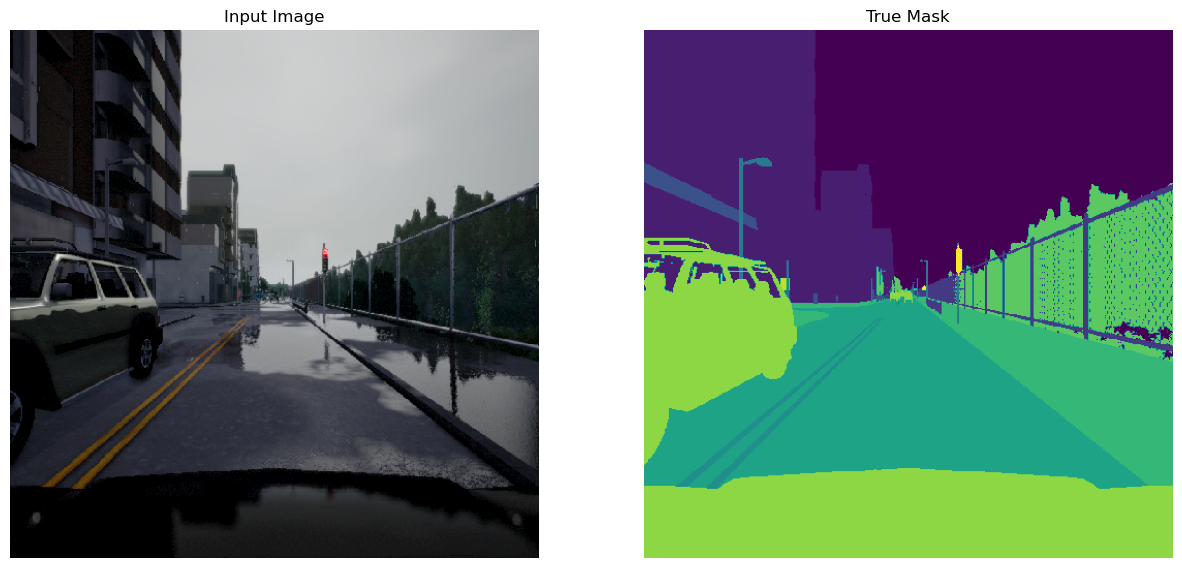

In [6]:
val_samples = 1000
train_img_paths = images[:-val_samples]
train_mask_paths = masks[:-val_samples]
val_img_paths = images[-val_samples:]
val_mask_paths = masks[-val_samples:]

train_data = get_dataset(32, train_img_paths, train_mask_paths)
val_data = get_dataset(32, val_img_paths, val_mask_paths)

for image, mask in train_data.take(1):
    display([image[0], mask[0]])